Visualizing one sample per digit...


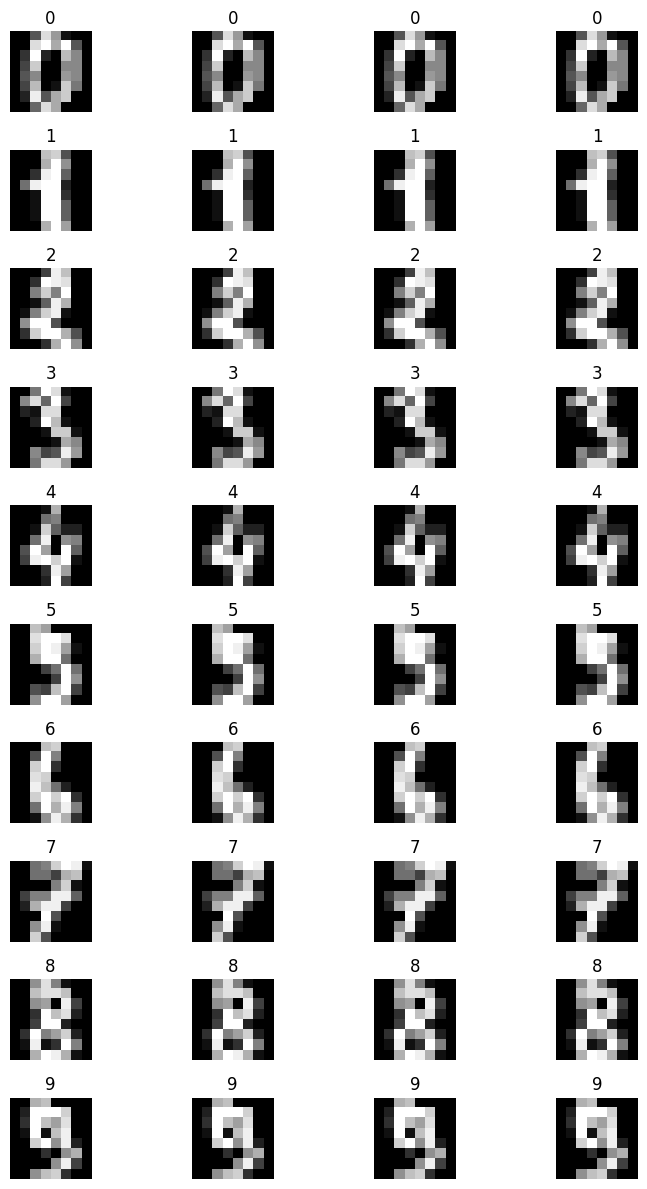

MLP accuracy on digits: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.94      0.93        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.91      0.89      0.90        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



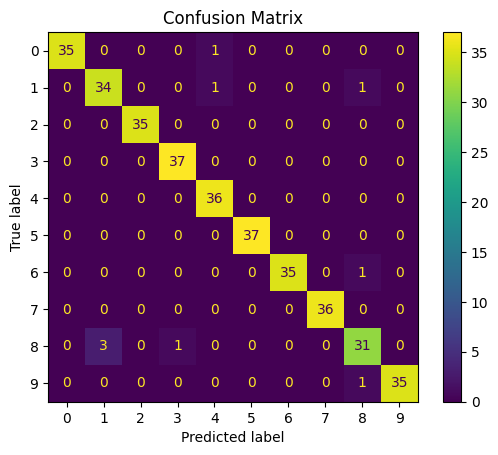

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def simple_mlp_demo():
    # Load data
    X, y = load_digits(return_X_y=True)

    # Visualize Dataset: Show samples of each digit (0-9)
    # We display them in a single row for a quick overview.
    print("Visualizing one sample per digit...")
    fig, axes = plt.subplots(10, 4, figsize=(8, 12))
    for j in range(4):
      for i in range(10):
          # Find the first sample of digit i
          sample_img = X[y == i][0].reshape(8, 8)
          axes[i,j].imshow(sample_img, cmap='gray')
          axes[i,j].set_title(f"{i}")
          axes[i,j].axis('off')
    plt.tight_layout()
    plt.show()

    # Split and Scale (Scaling is crucial for Neural Networks!)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Define MLP: 1 hidden layer with 64 neurons
    mlp = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=1
    )

    # Train
    mlp.fit(X_train_s, y_train)

    # Evaluate
    y_pred = mlp.predict(X_test_s)
    print("MLP accuracy on digits:", accuracy_score(y_test, y_pred))

    # Detailed classification report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Visualization of Confusion Matrix
    # (Requires matplotlib to be installed and a display environment)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Confusion Matrix")
    plt.show()
simple_mlp_demo()